In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, torch

class Config:
    PROJECT_ROOT   = '/content/drive/MyDrive/FinDocVQA'
    DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')
    DOCVQA_DIR     = os.path.join(DATA_DIR, 'docvqa')
    MODELS_DIR     = os.path.join(PROJECT_ROOT, 'models')
    OUTPUTS_DIR    = os.path.join(PROJECT_ROOT, 'outputs')
    LAYOUTLMV3_ID  = 'microsoft/layoutlmv3-base'
    SEED = 42

cfg = Config()
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
✓ GPU: Tesla T4


In [2]:
# ============================================================
# CELL 2: Install + Load data
# ============================================================

%%capture
!pip install transformers accelerate datasets sentencepiece protobuf
!pip install pytesseract
!apt-get -qq install tesseract-ocr

from datasets import load_from_disk
import numpy as np

docvqa = load_from_disk(os.path.join(cfg.DOCVQA_DIR, 'docvqa_dataset'))
print(f"✓ DocVQA loaded: {len(docvqa['validation'])} val examples")

In [3]:
# ============================================================
# CELL 3: Load LayoutLMv3 for DocVQA + Quick Test
# ============================================================
# LayoutLMv3 is encoder-only: it takes OCR words + bounding
# boxes + image, and predicts start/end answer positions in
# the OCR text. We use the DocVQA dataset's included OCR.
# ============================================================

from transformers import LayoutLMv3Processor, LayoutLMv3ForQuestionAnswering
from PIL import Image
from io import BytesIO
import torch
import json

LAYOUTLMV3_QA_ID = 'rubentito/layoutlmv3-base-mpdocvqa'

print("Loading LayoutLMv3...")
processor = LayoutLMv3Processor.from_pretrained(
    LAYOUTLMV3_QA_ID,
    apply_ocr=True  # processor will run Tesseract internally
)
model = LayoutLMv3ForQuestionAnswering.from_pretrained(LAYOUTLMV3_QA_ID)
model = model.to('cuda')
model.eval()

print(f"✓ Model loaded: {LAYOUTLMV3_QA_ID}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

def layoutlmv3_predict(image, question):
    """LayoutLMv3 prediction: OCR + spatial layout + image → answer span."""
    if isinstance(image, dict) and 'bytes' in image:
        image = Image.open(BytesIO(image['bytes']))
    image = image.convert('RGB')

    # Processor runs OCR, extracts bounding boxes, encodes image
    encoding = processor(
        image,
        question,
        return_tensors="pt",
        max_length=512,
        truncation=True,
        padding="max_length"
    )
    encoding = {k: v.to('cuda') for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)

    # Get predicted start/end positions
    start_idx = torch.argmax(outputs.start_logits, dim=1).item()
    end_idx = torch.argmax(outputs.end_logits, dim=1).item()

    # Make sure end >= start
    if end_idx < start_idx:
        end_idx = start_idx

    # Decode the answer tokens
    input_ids = encoding['input_ids'][0]
    answer_tokens = input_ids[start_idx : end_idx + 1]
    answer = processor.tokenizer.decode(answer_tokens, skip_special_tokens=True).strip()

    return answer

# --- Quick test ---
example = docvqa['validation'][0]
prediction = layoutlmv3_predict(example['image'], example['question'])
print(f"\nTest example:")
print(f"  Question: {example['question']}")
print(f"  Ground truth: {example['answers']}")
print(f"  Predicted: {prediction}")

Loading LayoutLMv3...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

LayoutLMv3ForQuestionAnswering LOAD REPORT from: rubentito/layoutlmv3-base-mpdocvqa
Key                                | Status     |  | 
-----------------------------------+------------+--+-
layoutlmv3.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

✓ Model loaded: rubentito/layoutlmv3-base-mpdocvqa
  Parameters: 125.9M

Test example:
  Question: what is the page no or page mentioned ?
  Ground truth: ['2', 'page 2']
  Predicted: 2


In [4]:
# ============================================================
# CELL 4: Evaluate LayoutLMv3 Zero-Shot on DocVQA Validation
# ============================================================

from tqdm import tqdm
import time
import json
import numpy as np

def normalized_levenshtein(s1, s2):
    s1, s2 = s1.lower().strip(), s2.lower().strip()
    if s1 == s2:
        return 1.0
    if len(s1) == 0 or len(s2) == 0:
        return 0.0
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    dist = dp[m][n]
    return 1.0 - (dist / max(m, n))

def compute_anls(prediction, ground_truths, threshold=0.5):
    if not prediction:
        return 0.0
    best = max(normalized_levenshtein(prediction, gt) for gt in ground_truths)
    return best if best >= threshold else 0.0

def compute_exact_match(prediction, ground_truths):
    pred = prediction.lower().strip()
    return float(any(pred == gt.lower().strip() for gt in ground_truths))

# --- Run evaluation on same 500 examples ---
NUM_EVAL = 500
val_data = docvqa['validation']
np.random.seed(42)
eval_indices = np.random.choice(len(val_data), NUM_EVAL, replace=False)

results = []
anls_scores = []
em_scores = []

print(f"Evaluating LayoutLMv3 on {NUM_EVAL} DocVQA validation examples...")
print("=" * 60)

start_time = time.time()

for i, idx in enumerate(tqdm(eval_indices, desc="Evaluating")):
    example = val_data[int(idx)]
    question = example['question']
    ground_truths = example['answers']

    try:
        prediction = layoutlmv3_predict(example['image'], question)
    except Exception as e:
        print(f"  Error on idx {idx}: {e}")
        prediction = ""

    anls = compute_anls(prediction, ground_truths)
    em = compute_exact_match(prediction, ground_truths)

    anls_scores.append(anls)
    em_scores.append(em)

    results.append({
        'index': int(idx),
        'question': question,
        'ground_truths': ground_truths,
        'prediction': prediction,
        'anls': anls,
        'exact_match': em,
    })

elapsed = time.time() - start_time

print("\n" + "=" * 60)
print(f"LAYOUTLMV3 RESULTS ({NUM_EVAL} examples)")
print("=" * 60)
print(f"  ANLS:         {np.mean(anls_scores):.4f}")
print(f"  Exact Match:  {np.mean(em_scores):.4f}")
print(f"  Time:         {elapsed:.0f}s ({elapsed/NUM_EVAL:.1f}s per example)")
print("=" * 60)
print(f"\n  vs Baseline:     ANLS +{np.mean(anls_scores) - 0.326:.4f}")
print(f"  vs Pix2Struct:   ANLS {np.mean(anls_scores) - 0.6548:+.4f}")
print(f"  vs Donut:        ANLS {np.mean(anls_scores) - 0.6265:+.4f}")

# Save results
results_path = os.path.join(cfg.OUTPUTS_DIR, 'layoutlmv3_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'model': f'LayoutLMv3 ({LAYOUTLMV3_QA_ID})',
        'dataset': 'DocVQA validation',
        'num_examples': NUM_EVAL,
        'anls': float(np.mean(anls_scores)),
        'exact_match': float(np.mean(em_scores)),
        'per_example': results
    }, f, indent=2)
print(f"\n✓ Results saved to {results_path}")

Evaluating LayoutLMv3 on 500 DocVQA validation examples...


Evaluating: 100%|██████████| 500/500 [19:26<00:00,  2.33s/it]


LAYOUTLMV3 RESULTS (500 examples)
  ANLS:         0.4683
  Exact Match:  0.3740
  Time:         1166s (2.3s per example)

  vs Baseline:     ANLS +0.1423
  vs Pix2Struct:   ANLS -0.1865
  vs Donut:        ANLS -0.1582

✓ Results saved to /content/drive/MyDrive/FinDocVQA/outputs/layoutlmv3_results.json


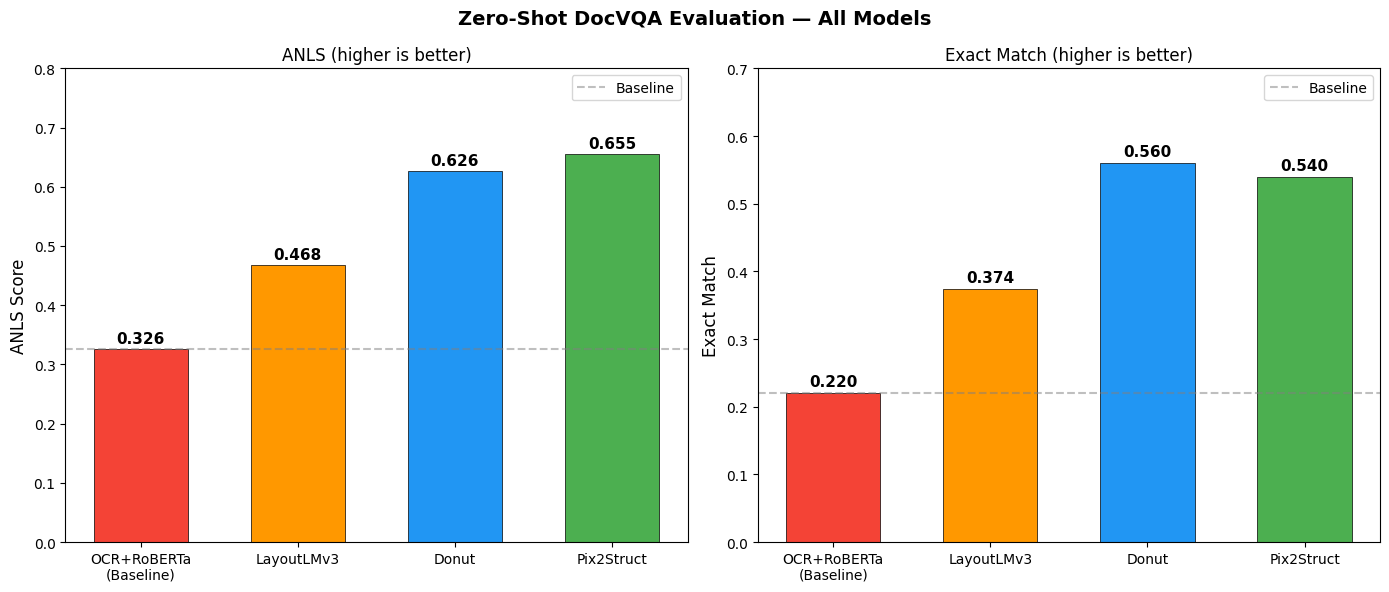

✓ Saved to outputs/zeroshot_comparison.png


In [5]:
# ============================================================
# CELL 5: Zero-Shot Comparison Chart
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = ['OCR+RoBERTa\n(Baseline)', 'LayoutLMv3', 'Donut', 'Pix2Struct']
anls =   [0.3260, 0.4683, 0.6265, 0.6548]
em =     [0.2200, 0.3740, 0.5600, 0.5400]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Zero-Shot DocVQA Evaluation — All Models', fontsize=14, fontweight='bold')

x = np.arange(len(models))
width = 0.6

# --- ANLS ---
ax = axes[0]
colors = ['#F44336', '#FF9800', '#2196F3', '#4CAF50']
bars = ax.bar(x, anls, width, color=colors, edgecolor='black', linewidth=0.5)
for bar, score in zip(bars, anls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('ANLS Score', fontsize=12)
ax.set_title('ANLS (higher is better)')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 0.8)
ax.axhline(y=0.326, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.legend()

# --- Exact Match ---
ax = axes[1]
bars = ax.bar(x, em, width, color=colors, edgecolor='black', linewidth=0.5)
for bar, score in zip(bars, em):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Exact Match', fontsize=12)
ax.set_title('Exact Match (higher is better)')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 0.7)
ax.axhline(y=0.220, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'zeroshot_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/zeroshot_comparison.png")